In [1]:
# 1. Mount Google Drive for persistent storage (so you never lose data when Colab restarts)
from google.colab import drive
drive.mount('/content/drive')

# 2. Install the HuggingFace ecosystem and visualization tools
!pip install -q transformers datasets evaluate
!pip install -q seaborn matplotlib pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 3. Set a clean, modern UI/UX aesthetic for our charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})
print("\n Environment setup complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 Environment setup complete!


In [2]:
print("Loading datasets from Google Drive...")

# Defining paths
true_path = '/content/drive/MyDrive/FakeNewsProject/True.csv'
fake_path = '/content/drive/MyDrive/FakeNewsProject/Fake.csv'

try:
    # Using robust parsing to skip broken HTML/text lines
    true_df = pd.read_csv(true_path, on_bad_lines='skip', engine='python')
    fake_df = pd.read_csv(fake_path, on_bad_lines='skip', engine='python')

    # Assigning labels: 1 for Real, 0 for Fake
    true_df['label'] = 1
    fake_df['label'] = 0

    # Combine and securely shuffle
    df = pd.concat([true_df, fake_df], ignore_index=True)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Feature Engineering: Combine Title and Text for maximum context
    df['combined_text'] = df['title'].fillna('') + ". " + df['text'].fillna('')

    # Basic Cleaning: Remove URLs and extra spaces
    def clean_text(text):
        text = re.sub(r'http\S+', '', text)
        return re.sub(r'\s+', ' ', text).strip()

    df['combined_text'] = df['combined_text'].apply(clean_text)

    print(f" Success! Total dataset size: {df.shape[0]} rows, {df.shape[1]} columns")

except Exception as e:
    print(f" Error loading data. Double-check your Google Drive folder. Details: {e}")

Loading datasets from Google Drive...
 Success! Total dataset size: 44898 rows, 6 columns


/tmp/ipykernel_12614/3912400718.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#E74C3C', '#2ECC71'])


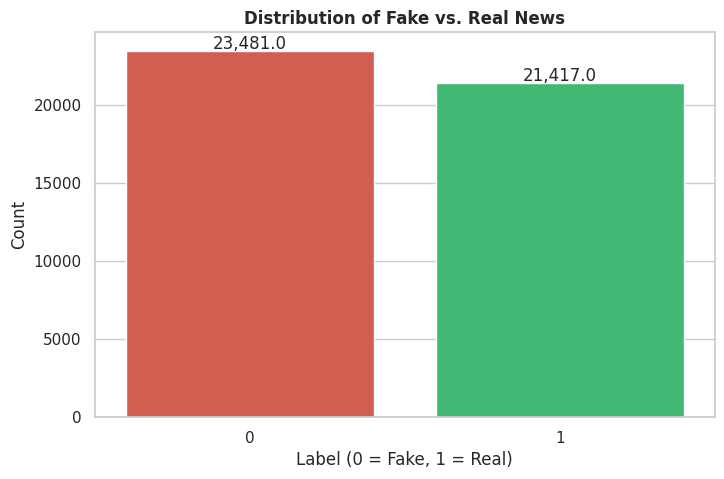


--- DATASET SUMMARY ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          44898 non-null  object
 1   text           44898 non-null  object
 2   subject        44898 non-null  object
 3   date           44898 non-null  object
 4   label          44898 non-null  int64 
 5   combined_text  44898 non-null  object
dtypes: int64(1), object(5)
memory usage: 2.1+ MB
None

--- LABEL DISTRIBUTION (%) ---
label
0    52.3
1    47.7
Name: proportion, dtype: float64

--- 5 SAMPLE ENTRIES ---


,combined_text,label
0,BREAKING: GOP Chairman Grassley Has Had Enough...,0
1,Failed GOP Candidates Remembered In Hilarious ...,0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY ...,0
3,California AG pledges to defend birth control ...,1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,0


In [3]:
# 1. Visual Label Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label', palette=['#E74C3C', '#2ECC71'])
plt.title('Distribution of Fake vs. Real News', fontweight='bold')
plt.xlabel('Label (0 = Fake, 1 = Real)')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

# 2. Print Mentor Deliverables
print("\n--- DATASET SUMMARY ---")
print(df.info())

print("\n--- LABEL DISTRIBUTION (%) ---")
print(df['label'].value_counts(normalize=True).round(4) * 100)

print("\n--- 5 SAMPLE ENTRIES ---")
display(df[['combined_text', 'label']].head(5))

In [4]:
from transformers import AutoTokenizer
from datasets import Dataset, DatasetDict

print("Loading DistilBERT Tokenizer...")
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Convert to HuggingFace Dataset
hg_dataset = Dataset.from_pandas(df[['combined_text', 'label']])

# Create Train (80%), Validation (10%), Test (10%) splits
train_testvalid = hg_dataset.train_test_split(test_size=0.2, seed=42)
test_valid = train_testvalid['test'].train_test_split(test_size=0.5, seed=42)

dataset_dict = DatasetDict({
    'train': train_testvalid['train'],
    'test': test_valid['test'],
    'valid': test_valid['train']
})

# Tokenize function: pad to max length, truncate at 512 tokens
def tokenize_function(examples):
    return tokenizer(examples["combined_text"], padding="max_length", truncation=True, max_length=512)

print("Tokenizing data (this takes a minute)...")
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Print Deliverables for Day 3
sample_batch = tokenized_datasets["train"][0]
print("\n--- SHAPE OF INPUT TENSORS ---")
print(f"Input IDs Shape: {sample_batch['input_ids'].shape}")
print(f"Attention Mask Shape: {sample_batch['attention_mask'].shape}")
print(" Tokenization complete and ready for the GPU!")

# Deliverable: Example tokenized output
sample_text = df['combined_text'][0]
print("\n--- EXAMPLE TOKENIZED OUTPUT ---")
print(f"Original: {sample_text[:80]}...")
print(f"Tokens: {tokenizer.tokenize(sample_text)[:10]}")
print(f"Input IDs: {tokenizer.convert_tokens_to_ids(tokenizer.tokenize(sample_text))[:10]}")

Loading DistilBERT Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizing data (this takes a minute)...


Map:   0%|          | 0/35918 [00:00<?, ? examples/s]

Map:   0%|          | 0/4490 [00:00<?, ? examples/s]

Map:   0%|          | 0/4490 [00:00<?, ? examples/s]


--- SHAPE OF INPUT TENSORS ---
Input IDs Shape: torch.Size([512])
Attention Mask Shape: torch.Size([512])
 Tokenization complete and ready for the GPU!

--- EXAMPLE TOKENIZED OUTPUT ---
Original: BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony. Don...
Tokens: ['breaking', ':', 'go', '##p', 'chairman', 'grass', '##ley', 'has', 'had', 'enough']
Input IDs: [4911, 1024, 2175, 2361, 3472, 5568, 3051, 2038, 2018, 2438]


In [5]:
import evaluate
import numpy as np

# Load industry-standard metrics
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Logits are raw, unnormalized scores. We use argmax to pick the highest score (0 or 1).
    predictions = np.argmax(logits, axis=-1)

    # Calculate accuracy
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]

    return {"accuracy": accuracy}

print(" Evaluation metrics loaded.")

 Evaluation metrics loaded.


In [14]:
# from transformers import AutoModelForSequenceClassification

# print("Downloading DistilBERT model with a classification head...")

# # num_labels=2 because we are predicting binary outcomes: 0 (Fake) or 1 (Real)
# model = AutoModelForSequenceClassification.from_pretrained(
#     model_ckpt,
#     num_labels=2
# )
# print("Model loaded and ready for fine-tuning.")

from transformers import AutoModelForSequenceClassification

print("🧠 Loading your fully trained model from Google Drive...")

# Instead of 'model_ckpt', we point directly to your saved folder!
saved_model_path = "/content/drive/MyDrive/FakeNewsProject/final_model"

model = AutoModelForSequenceClassification.from_pretrained(saved_model_path)
print("✅ Smart model loaded successfully!")

🧠 Loading your fully trained model from Google Drive...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Smart model loaded successfully!


In [15]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

# Senior-level hyperparameter choices (Updated for latest Transformers version)
training_args = TrainingArguments(
    output_dir="./fake_news_model_checkpoints",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    fp16=True,
    load_best_model_at_end=True,
)

# Instantiate the DataCollatorWithPadding to handle tokenization within the Trainer
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Instantiate the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["valid"],
    data_collator=data_collator, # Pass the data_collator instead of tokenizer directly
    compute_metrics=compute_metrics,
)
print(" Trainer successfully configured!")

 Trainer successfully configured!


In [8]:
# print("🚀 Starting Model Training... (This will take ~10-15 minutes)")

# # 1. Train the model (Outputs the Training Logs deliverable)
# trainer.train()

# # 2. Save the final model for deployment later
# trainer.save_model("/content/drive/MyDrive/FakeNewsProject/final_model")
# tokenizer.save_pretrained("/content/drive/MyDrive/FakeNewsProject/final_model")
# print("\n Model successfully saved to Google Drive!")

# # 3. Final Validation Accuracy Deliverable
# print("\n--- FINAL VALIDATION RESULTS ---")
# eval_results = trainer.evaluate()

# print(f"Final Validation Loss: {eval_results['eval_loss']:.4f}")
# print(f"Final Validation Accuracy: {eval_results['eval_accuracy'] * 100:.2f}%")

In [16]:
print(" Skipping training because model is already trained!")


# Final Validation Accuracy Deliverable
print("\n--- FINAL VALIDATION RESULTS ---")
eval_results = trainer.evaluate()

print(f"Final Validation Loss: {eval_results['eval_loss']:.4f}")
print(f"Final Validation Accuracy: {eval_results['eval_accuracy'] * 100:.2f}%")

 Skipping training because model is already trained!

--- FINAL VALIDATION RESULTS ---


Final Validation Loss: 0.0024
Final Validation Accuracy: 99.98%


In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 Running model on unseen Test Data...")

# Get predictions from the Trainer
test_results = trainer.predict(tokenized_datasets["test"])
y_preds = np.argmax(test_results.predictions, axis=-1)
y_true = test_results.label_ids

# Generate the comprehensive Classification Report
print("\n--- CLASSIFICATION REPORT ---")
target_names = ['Fake News (0)', 'Real News (1)']
report = classification_report(y_true, y_preds, target_names=target_names)
print(report)

🔍 Running model on unseen Test Data...



--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

Fake News (0)       1.00      1.00      1.00      2401
Real News (1)       1.00      1.00      1.00      2089

     accuracy                           1.00      4490
    macro avg       1.00      1.00      1.00      4490
 weighted avg       1.00      1.00      1.00      4490



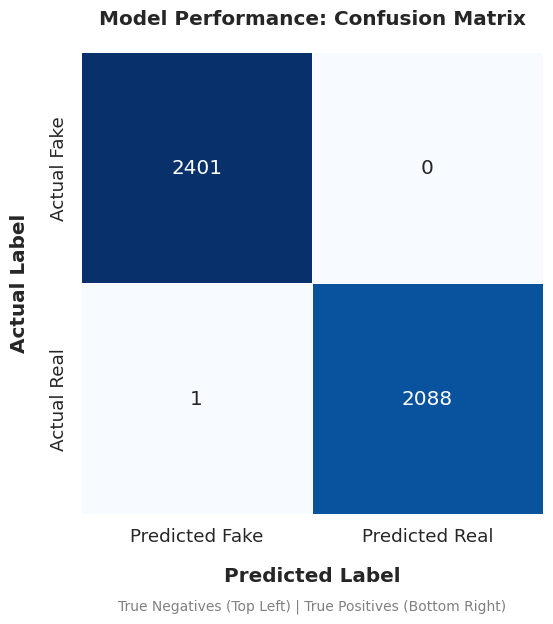

In [18]:
# Calculate the Confusion Matrix
cm = confusion_matrix(y_true, y_preds)

# UI/UX styling for the plot
plt.figure(figsize=(8, 6))
sns.set_context("notebook", font_scale=1.2)

# Create the Heatmap
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 cbar=False, linewidths=.5, square=True,
                 xticklabels=['Predicted Fake', 'Predicted Real'],
                 yticklabels=['Actual Fake', 'Actual Real'])

# Add clean, professional labels
plt.title('Model Performance: Confusion Matrix', fontweight='bold', pad=20)
plt.ylabel('Actual Label', fontweight='bold', labelpad=15)
plt.xlabel('Predicted Label', fontweight='bold', labelpad=15)

# Highlight the exact metrics
plt.text(0.5, -0.2, 'True Negatives (Top Left) | True Positives (Bottom Right)',
         ha='center', va='center', transform=ax.transAxes, fontsize=10, color='gray')

plt.show()

In [19]:
import pandas as pd

print("🕵️‍♂️ Hunting for model mistakes...\n")

# Decode the tokenized text back into readable English
test_texts = [tokenizer.decode(ids, skip_special_tokens=True) for ids in tokenized_datasets["test"]["input_ids"]]

# Create a clean DataFrame
error_analysis_df = pd.DataFrame({
    'Article_Text': test_texts,
    'Actual_Label': y_true,
    'Predicted_Label': y_preds
})

# Filter for the errors
errors = error_analysis_df[error_analysis_df['Actual_Label'] != error_analysis_df['Predicted_Label']]

false_positives = errors[(errors['Actual_Label'] == 0) & (errors['Predicted_Label'] == 1)]
false_negatives = errors[(errors['Actual_Label'] == 1) & (errors['Predicted_Label'] == 0)]

print(f"Total Errors Found: {len(errors)} out of {len(test_texts)} test samples")
print(f"🔴 False Positives (Fake news predicted as Real): {len(false_positives)}")
print(f"🟡 False Negatives (Real news predicted as Fake): {len(false_negatives)}\n")

print("--- 🚨 5 SAMPLES OF WRONG PREDICTIONS (Mentor Deliverable) ---")
pd.set_option('display.max_colwidth', None)
display(errors[['Article_Text', 'Actual_Label', 'Predicted_Label']].head(5))
pd.reset_option('display.max_colwidth')

🕵️‍♂️ Hunting for model mistakes...

Total Errors Found: 1 out of 4490 test samples
🔴 False Positives (Fake news predicted as Real): 0
🟡 False Negatives (Real news predicted as Fake): 1

--- 🚨 5 SAMPLES OF WRONG PREDICTIONS (Mentor Deliverable) ---


,Article_Text,Actual_Label,Predicted_Label
1655,"window closing for republican stealth assault on u. s. regulations. washington the clock began running out this week on a strategy that has provided u. s. republicans in congress with their only notable legislative successes this year : aggressive use of an obscure u. s. law known as the congressional review act ( cra ). on his 75th day in power, president donald trump has yet to offer any major legislation or win passage of a bill he favors, but house of representatives majority leader kevin mccarthy has notched numerous small - scale victories with his strategy. vice president mike pence told business leaders at the white house on tuesday that trump would sign more cra resolutions soon and roll back an “ avalanche of red tape ” from the administration of president barack obama, a democrat. reuters commentarywar college : one tank to rule them allthe right way to address the marines united facebook groupin legal battles against travel ban, trump ' s own statements are his worst enemy since trump took office on jan. 20, mccarthy has led congress in churning out 13 resolutions under the cra killing obama - era regulations, most of concern to business interests. trump has signed 11 of these into law, not only rolling back the rules they targeted but also barring agencies from writing “ substantially similar ” regulations in the future. white house spokesman sean spicer said on tuesday the number of resolutions signed over two months showed trump is “ vastly different ” from past presidents in rolling back regulations. on monday trump signed a cra resolution repealing broadband privacy protections. he has also signed resolutions killing rules meant to expand background checks for mentally ill gun purchasers, change public school assessments, and reduce coal waste runoff into streams. last friday was the deadline for introducing any new cra resolutions on regulations enacted by obama ’ s administration. now republicans must complete voting on resolutions already in the legislative pipeline by mid - may. democrats assail the reversals as harming the environment, education and checks on wall street, with many saying the regulations were killed in order to please big - money lobbyists. representative louise slaughter, the senior democrat on the rules committee that sends resolutions to the house floor for votes, said in an interview “ of course it benefits the lobbyists. ” but she said fumbles around healthcare and tax reform also pushed cra resolutions to the fore. “ partly i think it ’ s because they don ’ t have anything else to do, ” she said about republicans ’ eagerness. “ other than that i think it ’ s just another ‘ take that obama. ’ ”",1,0


In [23]:
!pip install -q streamlit



In [24]:

%%writefile app.py
import streamlit as st
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

st.set_page_config(page_title="VeriScan | AI News Detector", page_icon="📰", layout="wide")

st.markdown("""
    <style>
    .main { background-color: #f8f9fa; }
    .stButton>button { width: 100%; border-radius: 8px; font-weight: bold; background-color: #2C3E50; color: white; }
    .result-box { padding: 20px; border-radius: 10px; text-align: center; font-weight: 800; font-size: 24px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); }
    .real-news { background-color: #d1e7dd; color: #0f5132; border: 1px solid #badbcc; }
    .fake-news { background-color: #f8d7da; color: #842029; border: 1px solid #f5c2c7; }
    </style>
    """, unsafe_allow_html=True)

@st.cache_resource
def load_ai_model():
    model_path = "/content/drive/MyDrive/FakeNewsProject/final_model"
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    return tokenizer, model

try:
    tokenizer, model = load_ai_model()
    model_loaded = True
except Exception as e:
    st.error(f"Failed to load model from Google Drive. Ensure the path is correct. Error: {e}")
    model_loaded = False

with st.sidebar:
    st.image("https://cdn-icons-png.flaticon.com/512/2905/2905080.png", width=100)
    st.title("VeriScan Engine")
    st.info("**Architecture:** DistilBERT-base-uncased\n**Task:** Binary Sequence Classification\n**Token Limit:** 512 Max Length")
    st.divider()
    st.write("Built for the Advanced NLP Mini-Project.")

st.title("🔍 Fake News Detection AI")
st.write("Enter a news headline or full article below to evaluate its authenticity using our fine-tuned Transformer model.")

user_text = st.text_area("News Content", placeholder="Paste the news article here...", height=200)

if st.button("Analyze Authenticity") and model_loaded:
    if len(user_text.strip()) < 10:
        st.warning("⚠️ Please enter a longer text snippet for accurate analysis.")
    else:
        with st.spinner('Neural network is analyzing semantic patterns...'):
            inputs = tokenizer(user_text, truncation=True, padding=True, max_length=512, return_tensors="pt")
            with torch.no_grad():
                outputs = model(**inputs)
                probabilities = F.softmax(outputs.logits, dim=-1)
                confidence, prediction = torch.max(probabilities, dim=-1)

            is_real = prediction.item() == 1
            conf_score = confidence.item() * 100

            st.divider()
            if is_real:
                st.markdown('<div class="result-box real-news">✅ This article appears to be REAL NEWS.</div>', unsafe_allow_html=True)
            else:
                st.markdown('<div class="result-box fake-news">🚨 This article appears to be FAKE NEWS.</div>', unsafe_allow_html=True)

            st.write("")
            st.write(f"**AI Confidence Score:** {conf_score:.2f}%")
            st.progress(confidence.item())

Overwriting app.py


In [26]:
import time
import subprocess

print("🧹 1. Cleaning up old servers...")
!pkill -f streamlit
!pkill -f localtunnel
!pkill -f cloudflared

print("⬇️ 2. Downloading Cloudflare Tunnel...")
!wget -q -O - https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 > /tmp/cloudflared
!chmod +x /tmp/cloudflared

print("🚀 3. Booting up Streamlit...")
subprocess.Popen(["streamlit", "run", "app.py"])
time.sleep(4)

print("🌐 4. Establishing secure Cloudflare connection...")
!nohup /tmp/cloudflared tunnel --url http://localhost:8501 > cloudflare.log 2>&1 &
time.sleep(5)

print("\n" + "="*50)
print("✅ YOUR APP IS LIVE! Click the link below:")
!grep -o 'https://.*\.trycloudflare.com' cloudflare.log
print("="*50 + "\n")

🧹 1. Cleaning up old servers...
⬇️ 2. Downloading Cloudflare Tunnel...
🚀 3. Booting up Streamlit...
🌐 4. Establishing secure Cloudflare connection...

✅ YOUR APP IS LIVE! Click the link below:
https://arkansas-transport-educated-receivers.trycloudflare.com



In [27]:
%%writefile requirements.txt
transformers>=4.30.0
torch>=2.0.0
streamlit>=1.24.0
pandas
numpy
scikit-learn
evaluate
seaborn
matplotlib
datasets

Writing requirements.txt
